# PINN-MPC v6 Alpha: W0 MPPI Prediction Diagnostics v28

This notebook diagnoses why nominal MPPI still shows altitude-loss bias in W0.

It compares, at MPPI update times, the horizon rollout predicted by the PINN against an open-loop JSBSim rollout using the same selected elevator sequence from the same current state.

Default diagnostic:

- W0 nominal only
- MPPI samples: 32
- seed: 0
- records weighted MPPI sequence and best-cost sequence
- saves cost components and PINN-vs-JSBSim prediction errors

Interpretation: if PINN predicts altitude hold but JSBSim loses altitude, the issue is prediction mismatch. If PINN also predicts altitude loss but the cost still selects the sequence, the issue is cost calibration.


## 0. Install & Imports


In [33]:
!pip install jsbsim optuna -q
print('Install complete')


Install complete


In [34]:
import os, json, time, random, warnings, glob
warnings.filterwarnings('ignore')

import jsbsim
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import optuna

CKPT_FILENAME = 'pinn_dynamics_c172_2d_v6_alpha.pt'
COMPATIBLE_CKPT_FILENAMES = [
    'pinn_dynamics_c172_2d_v6_alpha.pt',
    'pinn_dynamics_c172_2d_v7_guidance_alpha.pt',
]
EXPERIMENT_FAMILY = 'PINN_MPC'
EXPERIMENT_NAME = 'v6_alpha_snc_smooth_pitch_doublet_W0_MPPI_prediction_diagnostics_v28_fix1'
RUN_STAMP = time.strftime('%Y%m%d_%H%M%S')
COLAB_DRIVE_MOUNTED = False

try:
    from google.colab import drive
    drive.mount('/content/drive')
    COLAB_DRIVE_MOUNTED = True
except Exception:
    COLAB_DRIVE_MOUNTED = False

# Current training notebook saves v6 alpha here. Older project paths are kept as
# fallbacks so old Drive layouts still work. If needed, override MODEL_PATH after
# this cell before running the checkpoint load cell.
MODEL_PATH_CANDIDATES = []
for _name in COMPATIBLE_CKPT_FILENAMES:
    MODEL_PATH_CANDIDATES += [
        f'/content/drive/MyDrive/PINN_MODEL_ONLY_v1/{_name}',
        f'/content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/current best/PINN_Model/{_name}',
        f'/content/drive/MyDrive/PINN_MPC_Project/current best/PINN_Model/{_name}',
        f'/content/drive/MyDrive/PINN_MPC_Project/PINN_Model/{_name}',
        f'/content/drive/MyDrive/Colab Result/PINN_MPC/{_name}',
        f'/content/{_name}',
        f'./PINN_MODEL_ONLY_v1/{_name}',
        f'./PINN_MPC_Project/current best/PINN_Model/{_name}',
        f'./{_name}',
    ]

CHECKPOINT_SEARCH_ROOTS = [
    '/content/drive/MyDrive',
    '/content',
    '.',
]


def find_checkpoint_candidates():
    found = []
    for candidate in MODEL_PATH_CANDIDATES:
        if candidate and os.path.exists(candidate):
            found.append(candidate)

    patterns = []
    for root in CHECKPOINT_SEARCH_ROOTS:
        if os.path.exists(root):
            patterns.append(os.path.join(root, '**', 'pinn_dynamics_c172_2d*.pt'))
            patterns.append(os.path.join(root, '**', '*v6_alpha*.pt'))
            patterns.append(os.path.join(root, '**', '*v7_guidance_alpha*.pt'))

    for pattern in patterns:
        try:
            found.extend(glob.glob(pattern, recursive=True))
        except Exception as exc:
            print('Checkpoint search skipped pattern:', pattern, '|', repr(exc))

    # De-duplicate while preserving order, then prefer exact v6 alpha names.
    unique = []
    seen = set()
    for item in found:
        item = os.path.abspath(item)
        if item not in seen and os.path.exists(item):
            unique.append(item)
            seen.add(item)

    def rank(path):
        name = os.path.basename(path)
        if name == 'pinn_dynamics_c172_2d_v6_alpha.pt':
            return (0, -os.path.getmtime(path))
        if name == 'pinn_dynamics_c172_2d_v7_guidance_alpha.pt':
            return (1, -os.path.getmtime(path))
        return (2, -os.path.getmtime(path))

    return sorted(unique, key=rank)


def resolve_model_path():
    candidates = find_checkpoint_candidates()
    if candidates:
        return candidates[0]
    return MODEL_PATH_CANDIDATES[0]


MODEL_PATH = resolve_model_path()
FOUND_MODEL_PATHS = find_checkpoint_candidates()

# Result policy: code stays in the repository; generated outputs go to a
# separate Colab Result folder. Each run gets a timestamped archive directory.
RESULT_ROOT = '/content/drive/MyDrive/Colab Result' if COLAB_DRIVE_MOUNTED else './Colab Result'
RESULT_MODEL_DIR = os.path.join(RESULT_ROOT, EXPERIMENT_FAMILY, EXPERIMENT_NAME)
RESULT_ARCHIVE_DIR = os.path.join(RESULT_MODEL_DIR, 'archive')
RESULT_LATEST_DIR = os.path.join(RESULT_MODEL_DIR, 'latest')
SAVE_DIR = os.path.join(RESULT_ARCHIVE_DIR, RUN_STAMP)
for _path in [RESULT_ROOT, RESULT_MODEL_DIR, RESULT_ARCHIVE_DIR, RESULT_LATEST_DIR, SAVE_DIR]:
    os.makedirs(_path, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('COLAB_DRIVE_MOUNTED:', COLAB_DRIVE_MOUNTED)
print('MODEL_PATH:', MODEL_PATH)
print('MODEL_EXISTS:', os.path.exists(MODEL_PATH))
print('FOUND_MODEL_PATHS:')
for item in FOUND_MODEL_PATHS[:20]:
    print(' -', item)
if len(FOUND_MODEL_PATHS) > 20:
    print(f' ... {len(FOUND_MODEL_PATHS) - 20} more')
print('RESULT_ROOT:', RESULT_ROOT)
print('RESULT_MODEL_DIR:', RESULT_MODEL_DIR)
print('SAVE_DIR:', SAVE_DIR)
print('RESULT_LATEST_DIR:', RESULT_LATEST_DIR)
if not os.path.exists(MODEL_PATH):
    print('No compatible checkpoint was found. Put one of these files in Drive:')
    for name in COMPATIBLE_CKPT_FILENAMES:
        print(' - /content/drive/MyDrive/PINN_MODEL_ONLY_v1/' + name)
    print('Or set MODEL_PATH manually before running the checkpoint load cell.')

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu
COLAB_DRIVE_MOUNTED: True
MODEL_PATH: /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/current best/PINN_Model/pinn_dynamics_c172_2d_v6_alpha.pt
MODEL_EXISTS: True
FOUND_MODEL_PATHS:
 - /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/current best/PINN_Model/pinn_dynamics_c172_2d_v6_alpha.pt
 - /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/_Archive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v5_2_warmstart.pt
 - /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/_Archive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v5_1_sequence.pt
 - /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/_Archive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d.pt
RESULT_ROOT: /content/drive/MyDrive/Colab Result
RESULT_MODEL_DIR: /content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_snc_smooth_pitch_doublet_W0_MPPI_prediction_diagnostics_v28_fix1
S

## 1. Configuration


In [35]:
# Run modes:
# - "quick": cost sanity check + fast PID vs MPPI comparison
# - "debug": MPPI-only short debug run
# - "single": PID vs MPPI with a little more time
# - "full": longer PID, Random Shooting, CEM, MPPI comparison
RUN_MODE = 'prediction_diagnostic'
DEBUG_STRICT_ASSERTS = False
NOTEBOOK_REVISION = 'v28_w0_mppi_prediction_diagnostics'

# PINN is loaded only. No PINN data collection or training is performed here.
PINN_LOAD_ONLY = True

# Enable this comparison to tune PID directly on JSBSim rollouts across
# nominal, positive-disturbance, and sign-reversed disturbance cases.
TUNE_PID_WITH_OPTUNA = False
DEFAULT_PID_PARAMS = {
    'kp_alt': 0.0,
    'kp': 2.4,
    'ki': 0.006,
    'kd': 0.45,
    'kq': 0.9,
}

INIT_ALT = 3000.0
TARGET_ALT = INIT_ALT
THROTTLE = 0.85
DT = 0.02
FPS_PER_KT = 1.6878098571
INIT_SPEED_KTS = 100.0
INIT_SPEED_FPS = INIT_SPEED_KTS * FPS_PER_KT

STATE_COLS = ['h', 'V', 'theta', 'q', 'alpha']
INPUT_COLS = ['elevator', 'prev_elevator', 'delevator']
FEAT_COLS = STATE_COLS + INPUT_COLS
TGT_COLS = ['dh', 'dV', 'dtheta', 'dq', 'dalpha']

REACHED_BAND_FT = 100.0
REACHED_HOLD_STEPS = 60

PITCH_LIMIT_DEG = 25.0
PITCH_ABORT_DEG = 65.0
ALPHA_LIMIT_DEG = 18.0
ALT_MIN_FT = 500.0
ALT_MAX_FT = 12000.0

ELEV_LIMIT = 0.45
DELTA_ELEV_LIMIT = 0.08

# Recompute MPC only every N JSBSim steps. Quick mode uses 0.20 s updates.
CONTROL_INTERVAL = 10

# Explicit controller-test guidance. This is not PINN training guidance.
GUIDANCE_KIND = 'smooth_pitch_doublet'
SIM_TIME_S = 30.0
GUIDANCE_CLIMB_RATE_FPS = 0.0
GUIDANCE_CLIMB_TIME_S = SIM_TIME_S
GUIDANCE_LINEAR_START_ALT_FT = INIT_ALT
GUIDANCE_LINEAR_TARGET_ALT_FT = TARGET_ALT
GUIDANCE_TRIM_ALPHA_RAD = 0.035
GUIDANCE_AIRSPEED_KTS = 95.0
GUIDANCE_AIRSPEED_FPS = GUIDANCE_AIRSPEED_KTS * FPS_PER_KT
SPEED_FLOOR_KTS = 75.0
SPEED_FLOOR_FPS = SPEED_FLOOR_KTS * FPS_PER_KT
SPEED_TRACK_SCALE_FPS = 12.0
TERMINAL_SPEED_SCALE_FPS = 9.0
SUSTAINED_AUTHORITY_SECONDS = SIM_TIME_S
SUSTAINED_MIN_SPEED_KTS = SPEED_FLOOR_KTS
SUSTAINED_MIN_SPEED_FPS = SPEED_FLOOR_FPS
MANEUVER_KIND = GUIDANCE_KIND
MANEUVER_START_S = 5.0
MANEUVER_HALF_PERIOD_S = 3.0
MANEUVER_TOTAL_TIME_S = 2.0 * MANEUVER_HALF_PERIOD_S
MANEUVER_RECOVERY_S = 12.0
PITCH_DOUBLET_AMPLITUDE_DEG = 5.0
PITCH_PULSE_AMPLITUDE_DEG = 6.0
PITCH_PUSHOVER_AMPLITUDE_DEG = -4.0
DISTURBANCE_KIND = 'none'
DISTURBANCE_START_S = 12.0
DISTURBANCE_END_S = 26.0
DISTURBANCE_ELEVATOR_BIAS = 0.0
DISTURBANCE_ELEVATOR_SINE_AMP = 0.0
DISTURBANCE_ELEVATOR_FREQ_HZ = 0.35
DISTURBANCE_CASES = [
    {'name': 'W0_nominal', 'kind': 'none', 'bias': 0.0, 'sine_amp': 0.0, 'freq_hz': 0.35, 'start_s': 12.0, 'end_s': 26.0},
]
PID_TUNING_CASE_NAMES = ['W0_nominal']
PID_TUNING_WEIGHTS = [1.0]
MPPI_SAMPLE_SWEEP = [32]
MPPI_SWEEP_SEEDS = [0]
DIAG_MPPI_SAMPLES = 32
DIAG_SEED = 0
DIAG_MAX_UPDATES = 30
ACTIVE_DISTURBANCE_CASE = dict(DISTURBANCE_CASES[0])
CURRENT_GUIDANCE_TIME = 0.0
GUIDANCE_ALT_TRACK_SCALE_FT = 10.0
ALT_HOLD_SCALE_FT = 35.0
ALT_TERMINAL_SCALE_FT = 25.0
ALT_VS_SCALE_FPS = 5.5
GUIDANCE_VS_SCALE_FPS = 6.5
GUIDANCE_Q_SCALE_RAD_S = 0.10
THETA_CMD_LIMIT = 0.18
THETA_TRACK_SCALE = 0.045
# Altitude-hold augmentation: add a small pitch bias when the aircraft loses
# altitude or has downward vertical speed. This makes both PID and MPPI track
# the same altitude-aware pitch reference instead of an open-loop pitch shape.
ALT_HOLD_GUIDANCE_ENABLE = True
ALT_HOLD_THETA_KP_DEG_PER_100FT = 2.2
ALT_HOLD_THETA_KV_DEG_PER_10FPS = 1.3
ALT_HOLD_THETA_LIMIT_DEG = 5.0
GLOBAL_ALT_SCALE_FT = 600.0
GUIDANCE_PROGRESS_SCALE_FT = 8.0

# MPPI is still stochastic, so a few deterministic anchor sequences are added
# to avoid missing the climb direction with very small sample counts.
MPPI_USE_ANCHOR_SEQUENCES = True
MPPI_ANCHOR_LEVELS = [-0.30, -0.15, 0.0, 0.15, 0.30]

if RUN_MODE == 'prediction_diagnostic':
    MAX_STEPS = 900
    PID_TRIALS = 0
    MPC_HORIZON = 100
    MPC_SAMPLES = DIAG_MPPI_SAMPLES
    CEM_ITERS = 1
    N_TEST_CASES = 1
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['MPPI']
elif RUN_MODE == 'sample_sweep':
    MAX_STEPS = 900
    PID_TRIALS = 0
    MPC_HORIZON = 100
    MPC_SAMPLES = 16
    CEM_ITERS = 1
    N_TEST_CASES = 1
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['MPPI']
elif RUN_MODE == 'quick':
    MAX_STEPS = 900
    PID_TRIALS = 0
    MPC_HORIZON = 100
    MPC_SAMPLES = 16
    CEM_ITERS = 1
    N_TEST_CASES = len(DISTURBANCE_CASES)
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['PID', 'MPPI']
elif RUN_MODE == 'optpid_fast':
    MAX_STEPS = 900
    PID_TRIALS = 14
    MPC_HORIZON = 100
    MPC_SAMPLES = 18
    CEM_ITERS = 1
    N_TEST_CASES = len(DISTURBANCE_CASES)
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['PID', 'MPPI']
elif RUN_MODE == 'debug':
    MAX_STEPS = 500
    PID_TRIALS = 0
    MPC_HORIZON = 100
    MPC_SAMPLES = 16
    CEM_ITERS = 1
    N_TEST_CASES = len(DISTURBANCE_CASES)
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['MPPI']
elif RUN_MODE == 'single':
    MAX_STEPS = int(SIM_TIME_S / DT)
    PID_TRIALS = 18
    MPC_HORIZON = 120
    MPC_SAMPLES = 12
    CEM_ITERS = 1
    N_TEST_CASES = len(DISTURBANCE_CASES)
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['PID', 'MPPI']
elif RUN_MODE == 'full':
    MAX_STEPS = int(SIM_TIME_S / DT)
    PID_TRIALS = 30
    MPC_HORIZON = 160
    MPC_SAMPLES = 20
    CEM_ITERS = 1
    N_TEST_CASES = 2
    SELECTED_CONTROLLERS = ['PID', 'Random', 'CEM', 'MPPI']
    TUNE_PID_WITH_OPTUNA = False
else:
    raise ValueError(f'Unknown RUN_MODE: {RUN_MODE}')

MPC_HORIZON_SECONDS = MPC_HORIZON * DT
CONTROL_INTERVAL_SECONDS = CONTROL_INTERVAL * DT
GUIDANCE_LINEAR_RATE_FPS = 0.0

CONFIG = dict(
    RUN_MODE=RUN_MODE,
    DEBUG_STRICT_ASSERTS=DEBUG_STRICT_ASSERTS,
    NOTEBOOK_REVISION=NOTEBOOK_REVISION,
    EXPERIMENT_FAMILY=EXPERIMENT_FAMILY,
    EXPERIMENT_NAME=EXPERIMENT_NAME,
    RUN_STAMP=RUN_STAMP,
    RESULT_ROOT=RESULT_ROOT,
    RESULT_MODEL_DIR=RESULT_MODEL_DIR,
    RESULT_ARCHIVE_DIR=RESULT_ARCHIVE_DIR,
    RESULT_LATEST_DIR=RESULT_LATEST_DIR,
    SAVE_DIR=SAVE_DIR,
    PINN_LOAD_ONLY=PINN_LOAD_ONLY,
    TUNE_PID_WITH_OPTUNA=TUNE_PID_WITH_OPTUNA,
    PID_TRIALS=PID_TRIALS,
    INIT_ALT=INIT_ALT,
    TARGET_ALT=TARGET_ALT,
    THROTTLE=THROTTLE,
    FPS_PER_KT=FPS_PER_KT,
    INIT_SPEED_KTS=INIT_SPEED_KTS,
    INIT_SPEED_FPS=INIT_SPEED_FPS,
    DT=DT,
    MAX_STEPS=MAX_STEPS,
    MPC_HORIZON=MPC_HORIZON,
    MPC_HORIZON_SECONDS=MPC_HORIZON_SECONDS,
    MPC_SAMPLES=MPC_SAMPLES,
    CEM_ITERS=CEM_ITERS,
    N_TEST_CASES=N_TEST_CASES,
    CONTROL_INTERVAL=CONTROL_INTERVAL,
    CONTROL_INTERVAL_SECONDS=CONTROL_INTERVAL_SECONDS,
    SELECTED_CONTROLLERS=SELECTED_CONTROLLERS,
    ELEV_LIMIT=ELEV_LIMIT,
    DELTA_ELEV_LIMIT=DELTA_ELEV_LIMIT,
    GUIDANCE_KIND=GUIDANCE_KIND,
    GUIDANCE_CLIMB_TIME_S=GUIDANCE_CLIMB_TIME_S,
    GUIDANCE_LINEAR_START_ALT_FT=GUIDANCE_LINEAR_START_ALT_FT,
    GUIDANCE_LINEAR_TARGET_ALT_FT=GUIDANCE_LINEAR_TARGET_ALT_FT,
    MANEUVER_KIND=MANEUVER_KIND,
    MANEUVER_TOTAL_TIME_S=MANEUVER_TOTAL_TIME_S,
    MANEUVER_START_S=MANEUVER_START_S,
    MANEUVER_HALF_PERIOD_S=MANEUVER_HALF_PERIOD_S,
    MANEUVER_RECOVERY_S=MANEUVER_RECOVERY_S,
    PITCH_DOUBLET_AMPLITUDE_DEG=PITCH_DOUBLET_AMPLITUDE_DEG,
    PITCH_PULSE_AMPLITUDE_DEG=PITCH_PULSE_AMPLITUDE_DEG,
    PITCH_PUSHOVER_AMPLITUDE_DEG=PITCH_PUSHOVER_AMPLITUDE_DEG,
    DISTURBANCE_CASES=DISTURBANCE_CASES,
    PID_TUNING_CASE_NAMES=PID_TUNING_CASE_NAMES,
    PID_TUNING_WEIGHTS=PID_TUNING_WEIGHTS,
    MPPI_SAMPLE_SWEEP=MPPI_SAMPLE_SWEEP,
    MPPI_SWEEP_SEEDS=MPPI_SWEEP_SEEDS,
    DIAG_MPPI_SAMPLES=DIAG_MPPI_SAMPLES,
    DIAG_SEED=DIAG_SEED,
    DIAG_MAX_UPDATES=DIAG_MAX_UPDATES,
    ACTIVE_DISTURBANCE_CASE=ACTIVE_DISTURBANCE_CASE,
    GUIDANCE_CLIMB_RATE_FPS=GUIDANCE_CLIMB_RATE_FPS,
    GUIDANCE_LINEAR_RATE_FPS=GUIDANCE_LINEAR_RATE_FPS,
    SIM_TIME_S=SIM_TIME_S,
    PID_ELEVATOR_SIGN=-1.0,
    EXPECTED_ALT_AT_SIM_END=GUIDANCE_LINEAR_TARGET_ALT_FT,
    SCENARIO_NOTE="Altitude-hold augmented smooth pitch-axis S&C maneuver: Optuna PID vs nominal PINN-MPPI with signed disturbances.",
    SPEED_UNIT_NOTE='JSBSim ic/vt-kts uses knots; PINN state V uses ft/s.',
    GUIDANCE_TRIM_ALPHA_RAD=GUIDANCE_TRIM_ALPHA_RAD,
    GUIDANCE_AIRSPEED_KTS=GUIDANCE_AIRSPEED_KTS,
    SPEED_FLOOR_KTS=SPEED_FLOOR_KTS,
    SPEED_FLOOR_FPS=SPEED_FLOOR_FPS,
    SPEED_TRACK_SCALE_FPS=SPEED_TRACK_SCALE_FPS,
    TERMINAL_SPEED_SCALE_FPS=TERMINAL_SPEED_SCALE_FPS,
    SUSTAINED_AUTHORITY_SECONDS=SUSTAINED_AUTHORITY_SECONDS,
    SUSTAINED_MIN_SPEED_KTS=SUSTAINED_MIN_SPEED_KTS,
    SUSTAINED_MIN_SPEED_FPS=SUSTAINED_MIN_SPEED_FPS,
    GUIDANCE_AIRSPEED_FPS=GUIDANCE_AIRSPEED_FPS,
    GUIDANCE_ALT_TRACK_SCALE_FT=GUIDANCE_ALT_TRACK_SCALE_FT,
    ALT_HOLD_SCALE_FT=ALT_HOLD_SCALE_FT,
    ALT_TERMINAL_SCALE_FT=ALT_TERMINAL_SCALE_FT,
    ALT_VS_SCALE_FPS=ALT_VS_SCALE_FPS,
    GUIDANCE_VS_SCALE_FPS=GUIDANCE_VS_SCALE_FPS,
    GUIDANCE_Q_SCALE_RAD_S=GUIDANCE_Q_SCALE_RAD_S,
    THETA_CMD_LIMIT=THETA_CMD_LIMIT,
    THETA_TRACK_SCALE=THETA_TRACK_SCALE,
    ALT_HOLD_GUIDANCE_ENABLE=ALT_HOLD_GUIDANCE_ENABLE,
    ALT_HOLD_THETA_KP_DEG_PER_100FT=ALT_HOLD_THETA_KP_DEG_PER_100FT,
    ALT_HOLD_THETA_KV_DEG_PER_10FPS=ALT_HOLD_THETA_KV_DEG_PER_10FPS,
    ALT_HOLD_THETA_LIMIT_DEG=ALT_HOLD_THETA_LIMIT_DEG,
    GLOBAL_ALT_SCALE_FT=GLOBAL_ALT_SCALE_FT,
    GUIDANCE_PROGRESS_SCALE_FT=GUIDANCE_PROGRESS_SCALE_FT,
    MPPI_USE_ANCHOR_SEQUENCES=MPPI_USE_ANCHOR_SEQUENCES,
    MPPI_ANCHOR_LEVELS=MPPI_ANCHOR_LEVELS,
)
print(json.dumps(CONFIG, indent=2))


{
  "RUN_MODE": "prediction_diagnostic",
  "DEBUG_STRICT_ASSERTS": false,
  "NOTEBOOK_REVISION": "v28_w0_mppi_prediction_diagnostics",
  "EXPERIMENT_FAMILY": "PINN_MPC",
  "EXPERIMENT_NAME": "v6_alpha_snc_smooth_pitch_doublet_W0_MPPI_prediction_diagnostics_v28_fix1",
  "RUN_STAMP": "20260503_051021",
  "RESULT_ROOT": "/content/drive/MyDrive/Colab Result",
  "RESULT_MODEL_DIR": "/content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_snc_smooth_pitch_doublet_W0_MPPI_prediction_diagnostics_v28_fix1",
  "RESULT_ARCHIVE_DIR": "/content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_snc_smooth_pitch_doublet_W0_MPPI_prediction_diagnostics_v28_fix1/archive",
  "RESULT_LATEST_DIR": "/content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_snc_smooth_pitch_doublet_W0_MPPI_prediction_diagnostics_v28_fix1/latest",
  "SAVE_DIR": "/content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_snc_smooth_pitch_doublet_W0_MPPI_prediction_diagnostics_v28_fix1/archive/20260503_051021",
  "PINN_LOAD_ONLY": true,
  "TUN

## 2. JSBSim Plant Helpers


In [36]:
def get_prop(fdm, name, default=0.0):
    try:
        return float(fdm[name])
    except Exception:
        return float(default)


def make_fdm(init_alt=INIT_ALT, init_speed=INIT_SPEED_KTS, init_pitch=0.0):
    fdm = jsbsim.FGFDMExec(None, None)
    fdm.set_debug_level(0)
    fdm.load_model('c172p')
    fdm['ic/h-sl-ft'] = float(init_alt)
    # JSBSim initial condition expects knots. read_state() returns ft/s.
    fdm['ic/vt-kts'] = float(init_speed)
    fdm['ic/theta-deg'] = float(init_pitch)
    fdm['ic/psi-true-deg'] = 0.0
    fdm.run_ic()
    fdm['propulsion/engine/set-running'] = 1
    fdm['fcs/throttle-cmd-norm'] = THROTTLE
    return fdm


def read_state(fdm):
    return np.array([
        get_prop(fdm, 'position/h-sl-ft'),
        get_prop(fdm, 'velocities/vt-fps'),
        get_prop(fdm, 'attitude/theta-rad'),
        get_prop(fdm, 'velocities/q-rad_sec'),
        get_prop(fdm, 'aero/alpha-rad', 0.0),
    ], dtype=np.float32)


def set_disturbance_case(case):
    global ACTIVE_DISTURBANCE_CASE
    ACTIVE_DISTURBANCE_CASE = dict(case)


def elevator_disturbance(t):
    case = ACTIVE_DISTURBANCE_CASE
    kind = case.get('kind', 'none')
    if kind in (None, 'none'):
        return 0.0
    start_s = float(case.get('start_s', DISTURBANCE_START_S))
    end_s = float(case.get('end_s', DISTURBANCE_END_S))
    if t < start_s or t > end_s:
        return 0.0
    tau = t - start_s
    bias = float(case.get('bias', 0.0))
    sine_amp = float(case.get('sine_amp', 0.0))
    freq_hz = float(case.get('freq_hz', DISTURBANCE_ELEVATOR_FREQ_HZ))
    if kind == 'elevator_step':
        return bias
    if kind == 'elevator_sine':
        return sine_amp * np.sin(2.0 * np.pi * freq_hz * tau)
    if kind == 'elevator_sine_step':
        return bias + sine_amp * np.sin(2.0 * np.pi * freq_hz * tau)
    raise ValueError(f'Unknown disturbance kind: {kind}')


def apply_control(fdm, elevator, t=0.0, disturbance=0.0):
    total_elevator = float(np.clip(elevator + disturbance, -1.0, 1.0))
    fdm['propulsion/engine/set-running'] = 1
    fdm['fcs/throttle-cmd-norm'] = THROTTLE
    fdm['fcs/elevator-cmd-norm'] = total_elevator
    fdm.run()
    return total_elevator


print('JSBSim helpers ready')


JSBSim helpers ready


## 3. Load Saved v6 Alpha PINN Checkpoint

This section reconstructs the network architecture and loads `model_state` from disk. It does not train, fit, optimize, or update the PINN parameters.


In [37]:
class PhysicsPINN(nn.Module):
    def __init__(self, hidden_dim=192, n_layers=4, stats=None):
        super().__init__()
        input_dim = len(FEAT_COLS)
        output_dim = len(TGT_COLS)
        self.register_buffer('Xm', stats['Xm'].clone() if stats else torch.zeros(input_dim))
        self.register_buffer('Xs', stats['Xs'].clone() if stats else torch.ones(input_dim))
        self.register_buffer('Ym', stats['Ym'].clone() if stats else torch.zeros(output_dim))
        self.register_buffer('Ys', stats['Ys'].clone() if stats else torch.ones(output_dim))

        layers = [nn.Linear(input_dim, hidden_dim), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x_norm):
        return self.net(x_norm)

    def denorm_delta(self, d_norm, add_mean=True):
        if add_mean:
            return d_norm * self.Ys + self.Ym
        return d_norm * self.Ys


def _torch_load_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def load_pinn_checkpoint(path):
    candidates = []
    if path and os.path.exists(path):
        candidates.append(path)
    candidates.extend([p for p in FOUND_MODEL_PATHS if p not in candidates])

    load_errors = []
    for candidate in candidates:
        try:
            ckpt = _torch_load_checkpoint(candidate)
            missing = [k for k in ['model_state', 'stats', 'best_params'] if k not in ckpt]
            if missing:
                load_errors.append(f'{candidate}: missing keys {missing}')
                continue
            ckpt_features = list(ckpt.get('feature_cols', FEAT_COLS))
            ckpt_targets = list(ckpt.get('target_cols', TGT_COLS))
            if ckpt_features != FEAT_COLS or ckpt_targets != TGT_COLS:
                load_errors.append(
                    f'{candidate}: contract mismatch features={ckpt_features}, targets={ckpt_targets}'
                )
                continue
            return ckpt, candidate
        except Exception as exc:
            load_errors.append(f'{candidate}: {type(exc).__name__}: {exc}')

    message = [
        'Missing compatible trained PINN checkpoint.',
        f'Initial MODEL_PATH: {path}',
        'Expected feature contract:', str(FEAT_COLS),
        'Expected target contract:', str(TGT_COLS),
        'Searched/found candidates:',
    ]
    message += [f' - {p}' for p in (FOUND_MODEL_PATHS or MODEL_PATH_CANDIDATES[:10])]
    if load_errors:
        message += ['Load attempts:'] + [f' - {err}' for err in load_errors]
    message += [
        'Fix: run the v6 training notebook first, or copy a compatible checkpoint to:',
        '/content/drive/MyDrive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v6_alpha.pt',
        'You can also set MODEL_PATH manually before this cell.',
    ]
    raise FileNotFoundError('\n'.join(message))


assert PINN_LOAD_ONLY is True
checkpoint, MODEL_PATH = load_pinn_checkpoint(MODEL_PATH)

stats = {k: v.to(device) for k, v in checkpoint['stats'].items()}
params = checkpoint['best_params']

model = PhysicsPINN(
    hidden_dim=params.get('hidden_dim', 192),
    n_layers=params.get('n_layers', 4),
    stats=stats,
).to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

ckpt_feature_cols = checkpoint.get('feature_cols', FEAT_COLS)
ckpt_target_cols = checkpoint.get('target_cols', TGT_COLS)

print('Loaded compatible PINN checkpoint:', MODEL_PATH)
print('PINN parameters frozen:', not any(p.requires_grad for p in model.parameters()))
print('best_params:', params)
print('feature_cols:', ckpt_feature_cols)
print('target_cols:', ckpt_target_cols)
print('auto_summary:', json.dumps(checkpoint.get('auto_summary', {}), indent=2))


Loaded compatible PINN checkpoint: /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/current best/PINN_Model/pinn_dynamics_c172_2d_v6_alpha.pt
PINN parameters frozen: True
best_params: {'hidden_dim': 192, 'n_layers': 4, 'lr': 0.0005, 'lam_physics': 0.1, 'lam_smooth': 0.0005, 'lam_rollout': 0.1, 'target_weights': [1.0, 1.0, 2.0, 8.0, 2.0], 'epochs': 340}
feature_cols: ['h', 'V', 'theta', 'q', 'alpha', 'elevator', 'prev_elevator', 'delevator']
target_cols: ['dh', 'dV', 'dtheta', 'dq', 'dalpha']
auto_summary: {
  "best_cycle": 0,
  "best_rollout_score_val": 0.3200063483543797,
  "best_h_rmse_mean_val": 0.37132277619093657,
  "best_theta_rmse_mean_val": 0.0007993993785930797,
  "best_q_rmse_mean_val": 0.0018216835087514482,
  "final_rollout_score_test": 0.1880706141043144,
  "final_h_rmse_mean_test": 0.21852892497554421,
  "final_theta_rmse_mean_test": 0.0006437486226786859,
  "final_q_rmse_mean_test": 0.0007485623646061867,
  "test_targets_met": true,
  "auto_cycles_run": 0,
  "auto

## 4. PINN Rollout for Control


In [38]:
@torch.no_grad()
def pinn_step(model, state, elevator, prev_elevator):
    elevator = float(np.clip(elevator, -ELEV_LIMIT, ELEV_LIMIT))
    prev_elevator = float(np.clip(prev_elevator, -ELEV_LIMIT, ELEV_LIMIT))
    delevator = elevator - prev_elevator
    x = np.array([state[0], state[1], state[2], state[3], state[4],
                  elevator, prev_elevator, delevator], dtype=np.float32)
    xt = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0)
    xn = (xt - model.Xm) / model.Xs
    dn = model(xn)
    delta = model.denorm_delta(dn, add_mean=True).cpu().numpy()[0]
    return state + delta


@torch.no_grad()
def rollout_pinn_control(model, init_state, elevator_seq, prev_elevator):
    states = [np.asarray(init_state, dtype=np.float32).copy()]
    current = states[0].copy()
    prev = float(prev_elevator)
    applied = []
    for raw_elev in elevator_seq:
        elev = float(np.clip(raw_elev, prev - DELTA_ELEV_LIMIT, prev + DELTA_ELEV_LIMIT))
        elev = float(np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT))
        current = pinn_step(model, current, elev, prev)
        states.append(current.copy())
        applied.append(elev)
        prev = elev
    return np.asarray(states), np.asarray(applied, dtype=np.float32)


print('PINN control rollout ready')


PINN control rollout ready


## 5. PID Baseline Tuning


In [39]:
class TunedPID:
    def __init__(self, params):
        self.kp_alt = params.get('kp_alt', 0.0)
        self.kp = params['kp']
        self.ki = params['ki']
        self.kd = params['kd']
        self.kq = params.get('kq', 0.0)
        self.integral = 0.0
        self.prev_err = 0.0
        self.prev_elev = 0.0
        self.ILIM = 8.0

    def reset(self):
        self.integral = 0.0
        self.prev_err = 0.0
        self.prev_elev = 0.0

    def update(self, state, target_alt):
        h, V, theta, q, alpha = state
        theta_cmd = guidance_first_theta(state, target_alt)
        err = theta_cmd - theta
        self.integral = np.clip(self.integral + err * DT, -self.ILIM, self.ILIM)
        deriv = (err - self.prev_err) / DT
        self.prev_err = err

        raw_cmd = self.kp * err + self.ki * self.integral + self.kd * deriv - self.kq * q
        raw = -raw_cmd
        elev = np.clip(raw, self.prev_elev - DELTA_ELEV_LIMIT, self.prev_elev + DELTA_ELEV_LIMIT)
        elev = np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT)
        self.prev_elev = float(elev)
        return float(elev), {'theta_cmd': float(theta_cmd), 'cost': abs(theta_cmd - theta)}


def eval_pid_params(params, case=None, init_alt=INIT_ALT, target_alt=TARGET_ALT, n_steps=None):
    case = DISTURBANCE_CASES[0] if case is None else case
    set_disturbance_case(case)
    controller = TunedPID(params)
    fdm = make_fdm(init_alt=init_alt, init_speed=INIT_SPEED_KTS)
    n_steps = int(SIM_TIME_S / DT) if n_steps is None else int(n_steps)
    pitch, theta_ref, q_vals, alpha_vals, elevs, alt, speed = [], [], [], [], [], [], []

    global CURRENT_GUIDANCE_TIME
    for step in range(n_steps):
        t_now = step * DT
        CURRENT_GUIDANCE_TIME = t_now
        state = read_state(fdm)
        h, V, theta, q, alpha = state
        if h < ALT_MIN_FT or h > ALT_MAX_FT or abs(np.degrees(theta)) > PITCH_ABORT_DEG:
            return 1e8
        elev, info = controller.update(state, target_alt)
        disturb = elevator_disturbance(t_now)
        applied = apply_control(fdm, elev, t=t_now, disturbance=disturb)
        pitch.append(np.degrees(theta))
        theta_ref.append(np.degrees(info['theta_cmd']))
        q_vals.append(np.degrees(q))
        alpha_vals.append(np.degrees(alpha))
        elevs.append(applied)
        alt.append(h)
        speed.append(V)

    pitch = np.asarray(pitch)
    theta_ref = np.asarray(theta_ref)
    q_vals = np.asarray(q_vals)
    alpha_vals = np.asarray(alpha_vals)
    elevs = np.asarray(elevs)
    alt = np.asarray(alt)
    speed = np.asarray(speed)
    err = pitch - theta_ref

    pitch_rmse = np.sqrt(np.nanmean(err ** 2))
    peak_err = np.nanmax(np.abs(err))
    final_err = abs(err[-1])
    pitch_pen = 2.0 * np.mean(np.maximum(0.0, np.abs(pitch) - PITCH_LIMIT_DEG) ** 2)
    alpha_pen = 2.0 * np.mean(np.maximum(0.0, np.abs(alpha_vals) - ALPHA_LIMIT_DEG) ** 2)
    q_pen = 0.015 * np.mean(q_vals ** 2)
    effort = 2.0 * np.mean(np.diff(elevs, prepend=elevs[0]) ** 2)
    alt_pen = 0.002 * np.sqrt(np.mean((alt - target_alt) ** 2))
    alt_rmse = np.sqrt(np.mean((alt - target_alt) ** 2))
    final_alt_err = abs(alt[-1] - target_alt)
    speed_floor_pen = np.mean(np.maximum(0.0, SPEED_FLOOR_FPS - speed) / SPEED_TRACK_SCALE_FPS)
    speed_ref_pen = np.sqrt(np.mean(((speed - GUIDANCE_AIRSPEED_FPS) / SPEED_TRACK_SCALE_FPS) ** 2))
    # Tune PID on the same priorities used for the MPPI comparison: pitch first,
    # but do not allow the controller to buy pitch tracking with altitude/speed loss.
    return float(
        1.15 * pitch_rmse
        + 0.22 * peak_err
        + 0.12 * final_err
        + 0.045 * alt_rmse
        + 0.035 * final_alt_err
        + 0.20 * speed_floor_pen
        + 0.05 * speed_ref_pen
        + pitch_pen + alpha_pen + q_pen + effort
    )


def pid_objective(trial):
    params = {
        'kp_alt': 0.0,
        'kp': trial.suggest_float('kp', 0.15, 5.0, log=True),
        'ki': trial.suggest_float('ki', 0.0001, 0.08, log=True),
        'kd': trial.suggest_float('kd', 0.01, 2.5, log=True),
        'kq': trial.suggest_float('kq', 0.0, 2.5),
    }
    case_map = {case['name']: case for case in DISTURBANCE_CASES}
    tuning_cases = [case_map[name] for name in PID_TUNING_CASE_NAMES]
    return sum(w * eval_pid_params(params, case) for w, case in zip(PID_TUNING_WEIGHTS, tuning_cases))


def tune_pid_if_requested():
    global PID_PARAMS
    if TUNE_PID_WITH_OPTUNA and PID_TRIALS > 0:
        print(f'Tuning PID gains with {PID_TRIALS} Optuna trials on cases {PID_TUNING_CASE_NAMES}.')
        pid_study = optuna.create_study(direction='minimize')
        pid_study.optimize(pid_objective, n_trials=PID_TRIALS, show_progress_bar=True)
        PID_PARAMS = dict(pid_study.best_params)
        PID_PARAMS['kp_alt'] = 0.0
        print('Best PID params:', PID_PARAMS)
        print('Best PID objective:', pid_study.best_value)
        return pid_study
    PID_PARAMS = dict(DEFAULT_PID_PARAMS)
    print('Using DEFAULT_PID_PARAMS without Optuna:', PID_PARAMS)
    return None


PID_PARAMS = dict(DEFAULT_PID_PARAMS)
print('PID class and Optuna tuner ready')


PID class and Optuna tuner ready


## 6. MPC Cost Function


In [40]:
def _as_state_vector(current_state):
    arr = np.asarray(current_state, dtype=np.float32)
    if arr.ndim == 0 or arr.size == 1:
        return np.array([INIT_ALT, GUIDANCE_AIRSPEED_FPS, 0.0, 0.0, GUIDANCE_TRIM_ALPHA_RAD], dtype=np.float32)
    if arr.size < 5:
        raise ValueError('Guidance requires state [h, V, theta, q, alpha] or a scalar fallback.')
    return arr[:5].astype(np.float32)


def pitch_maneuver_theta_profile(t_abs):
    t_abs = np.asarray(t_abs, dtype=np.float32)
    theta_deg = np.zeros_like(t_abs, dtype=np.float32)
    a = float(PITCH_DOUBLET_AMPLITUDE_DEG)
    t0 = float(MANEUVER_START_S)
    half = float(MANEUVER_HALF_PERIOD_S)
    tau = t_abs - t0

    if MANEUVER_KIND in ('smooth_pitch_doublet', 'pitch_doublet'):
        first = (tau >= 0.0) & (tau < half)
        second = (tau >= half) & (tau < 2.0 * half)
        # Smooth S&C-style doublet: each lobe starts and ends at zero with a
        # half-sine shape, avoiding an impossible pitch step command.
        theta_deg[first] = a * np.sin(np.pi * tau[first] / half)
        theta_deg[second] = -a * np.sin(np.pi * (tau[second] - half) / half)
    elif MANEUVER_KIND == 'pullup_pushover':
        first = (tau >= 0.0) & (tau < half)
        second = (tau >= half) & (tau < 2.0 * half)
        theta_deg[first] = float(PITCH_PULSE_AMPLITUDE_DEG) * np.sin(np.pi * tau[first] / half)
        theta_deg[second] = float(PITCH_PUSHOVER_AMPLITUDE_DEG) * np.sin(np.pi * (tau[second] - half) / half)
    else:
        raise ValueError(f'Unknown MANEUVER_KIND: {MANEUVER_KIND}')
    return np.deg2rad(theta_deg).astype(np.float32)




def maneuver_reference_arrays(t, target_alt=TARGET_ALT):
    t = np.asarray(t, dtype=float)
    theta_ref_deg = np.degrees(pitch_maneuver_theta_profile(t))
    h_ref = np.ones_like(t) * float(target_alt)
    return h_ref, theta_ref_deg


def altitude_hold_theta_correction(h, h_ref, vz=None, vz_ref=0.0):
    h = np.asarray(h, dtype=np.float32)
    h_ref = np.asarray(h_ref, dtype=np.float32)
    alt_err = h_ref - h
    corr_deg = ALT_HOLD_THETA_KP_DEG_PER_100FT * (alt_err / 100.0)
    if vz is not None:
        vz = np.asarray(vz, dtype=np.float32)
        corr_deg += ALT_HOLD_THETA_KV_DEG_PER_10FPS * ((float(vz_ref) - vz) / 10.0)
    corr_deg = np.clip(corr_deg, -ALT_HOLD_THETA_LIMIT_DEG, ALT_HOLD_THETA_LIMIT_DEG)
    return np.deg2rad(corr_deg).astype(np.float32)


def make_pitch_maneuver_guidance(current_state, target_alt, horizon, dt):
    state = _as_state_vector(current_state)
    h0, V0, theta0, q0, alpha0 = [float(v) for v in state]
    horizon = int(horizon)
    if horizon <= 0:
        raise ValueError('horizon must be positive')

    t_rel = np.arange(horizon, dtype=np.float32) * float(dt)
    t_abs = float(CURRENT_GUIDANCE_TIME) + t_rel
    theta_base_ref = pitch_maneuver_theta_profile(t_abs)
    h_ref = np.ones(horizon, dtype=np.float32) * float(target_alt)
    if ALT_HOLD_GUIDANCE_ENABLE:
        # For the controller command, use the current altitude error as the
        # immediate pitch bias. The MPC cost adds a trajectory-wise correction
        # below using each predicted altitude sequence.
        theta_ref = theta_base_ref + altitude_hold_theta_correction(h0, h_ref, vz=0.0, vz_ref=0.0)
    else:
        theta_ref = theta_base_ref
    theta_ref = np.clip(theta_ref, -THETA_CMD_LIMIT, THETA_CMD_LIMIT).astype(np.float32)
    q_ref = np.gradient(theta_ref, dt).astype(np.float32)
    vz_ref = np.zeros(horizon, dtype=np.float32)
    speed_ref = np.ones(horizon, dtype=np.float32) * GUIDANCE_AIRSPEED_FPS
    alpha_ref = np.ones(horizon, dtype=np.float32) * np.clip(
        GUIDANCE_TRIM_ALPHA_RAD if abs(alpha0) < 0.20 else alpha0,
        -0.12, 0.16,
    )
    return {
        'h_ref': h_ref,
        'vz_ref': vz_ref,
        'V_ref': speed_ref.astype(np.float32),
        'theta_ref': theta_ref,
        'theta_base_ref': theta_base_ref.astype(np.float32),
        'q_ref': q_ref,
        'alpha_ref': alpha_ref,
        'target_alt': float(target_alt),
        'desired_vs': 0.0,
        'initial_error': float(target_alt - h0),
        'profile': MANEUVER_KIND,
        't_abs': t_abs.astype(np.float32),
    }


def make_linear_altitude_guidance(current_state, target_alt, horizon, dt):
    return make_pitch_maneuver_guidance(current_state, target_alt, horizon, dt)


def make_maneuver_guidance(current_state, target_alt, horizon, dt, maneuver='pitch_doublet'):
    return make_pitch_maneuver_guidance(current_state, target_alt, horizon, dt)


def make_mpc_altitude_guidance(current_state, target_alt, horizon, dt):
    return make_maneuver_guidance(current_state, target_alt, horizon, dt, maneuver=GUIDANCE_KIND)


def make_altitude_guidance(current_state, target_alt, horizon, dt):
    guide = make_mpc_altitude_guidance(current_state, target_alt, horizon, dt)
    return guide['h_ref'], guide['vz_ref'], guide['theta_ref']


def guidance_first_theta(current_state, target_alt):
    guide = make_mpc_altitude_guidance(current_state, target_alt, 2, DT)
    return float(guide['theta_ref'][0])


def mpc_cost_components(predicted, target_alt, elev_seq):
    h = predicted[:, 0]
    V = predicted[:, 1]
    theta = predicted[:, 2]
    q = predicted[:, 3]
    alpha = predicted[:, 4]
    elev_seq = np.asarray(elev_seq, dtype=np.float32)

    guide = make_mpc_altitude_guidance(predicted[0], target_alt, len(h), DT)
    h_ref = guide['h_ref']
    theta_ref = guide['theta_ref']
    q_ref = guide['q_ref']
    alpha_ref = guide['alpha_ref']
    V_ref = guide['V_ref']

    dhdt = np.diff(h, prepend=h[0]) / DT
    if ALT_HOLD_GUIDANCE_ENABLE:
        theta_base_ref = guide.get('theta_base_ref', theta_ref)
        theta_ref = theta_base_ref + altitude_hold_theta_correction(h, guide['h_ref'], vz=dhdt, vz_ref=0.0)
        theta_ref = np.clip(theta_ref, -THETA_CMD_LIMIT, THETA_CMD_LIMIT).astype(np.float32)
        q_ref = np.gradient(theta_ref, DT).astype(np.float32)
    theta_deg = np.degrees(theta)
    q_deg = np.degrees(q)
    alpha_deg = np.degrees(alpha)

    components = {
        'theta_track': 9.50 * np.mean(((theta - theta_ref) / THETA_TRACK_SCALE) ** 2),
        'theta_terminal': 5.00 * ((theta[-1] - theta_ref[-1]) / THETA_TRACK_SCALE) ** 2,
        'q_track': 0.20 * np.mean(((q - q_ref) / GUIDANCE_Q_SCALE_RAD_S) ** 2),
        'alpha_track': 0.05 * np.mean(((alpha - alpha_ref) / max(np.deg2rad(8.0), 1e-6)) ** 2),
        'alt_hold': 3.20 * np.mean(((h - h_ref) / ALT_HOLD_SCALE_FT) ** 2),
        'alt_terminal': 6.00 * ((h[-1] - h_ref[-1]) / ALT_TERMINAL_SCALE_FT) ** 2,
        'alt_low': 3.00 * np.mean((np.maximum(0.0, h_ref - h) / ALT_HOLD_SCALE_FT) ** 2),
        'alt_terminal_low': 5.00 * (max(0.0, float(h_ref[-1] - h[-1])) / ALT_TERMINAL_SCALE_FT) ** 2,
        'vz_hold': 1.80 * np.mean((dhdt / ALT_VS_SCALE_FPS) ** 2),
        'speed_track': 1.10 * np.mean(((V - V_ref) / SPEED_TRACK_SCALE_FPS) ** 2),
        'terminal_speed': 1.00 * ((V[-1] - V_ref[-1]) / TERMINAL_SPEED_SCALE_FPS) ** 2,
        'speed_floor': 3.00 * np.mean((np.maximum(0.0, SPEED_FLOOR_FPS - V) / SPEED_TRACK_SCALE_FPS) ** 2),
        'pitch_limit': 25.0 * np.mean(np.maximum(0.0, np.abs(theta_deg) - PITCH_LIMIT_DEG) ** 2),
        'alpha_limit': 25.0 * np.mean(np.maximum(0.0, np.abs(alpha_deg) - ALPHA_LIMIT_DEG) ** 2),
        'q_penalty': 0.004 * np.mean(q_deg ** 2),
        'effort': 0.003 * np.mean(elev_seq ** 2) if len(elev_seq) else 0.0,
        'smooth': 0.020 * np.mean(np.diff(elev_seq, prepend=elev_seq[0]) ** 2) if len(elev_seq) else 0.0,
    }

    unsafe = np.any((h < ALT_MIN_FT) | (h > ALT_MAX_FT) | (np.abs(theta_deg) > PITCH_ABORT_DEG))
    components['abort'] = 1e3 if unsafe else 0.0
    components = {k: float(v) for k, v in components.items()}
    components['total'] = float(sum(components.values()))
    return components, guide


def mpc_cost(predicted, target_alt, elev_seq):
    components, _ = mpc_cost_components(predicted, target_alt, elev_seq)
    return components['total']


## 7. PINN-MPC Controllers


In [41]:
class RandomShootingMPC:
    def __init__(self, horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.20):
        self.horizon = horizon
        self.n_samples = n_samples
        self.sigma = sigma
        self.U = np.zeros(horizon, dtype=np.float32)
        self.prev_elev = 0.0
        self.last_diag = None

    def reset(self):
        self.U[:] = 0.0
        self.prev_elev = 0.0
        self.last_diag = None

    def sample_sequences(self):
        noise = np.random.normal(0.0, self.sigma, size=(self.n_samples, self.horizon))
        return np.clip(self.U[None, :] + noise, -ELEV_LIMIT, ELEV_LIMIT)

    def update(self, state, target_alt):
        seqs = self.sample_sequences()
        costs = np.empty(self.n_samples)
        applied_cache = []
        for i, seq in enumerate(seqs):
            pred, applied = rollout_pinn_control(model, state, seq, self.prev_elev)
            costs[i] = mpc_cost(pred, target_alt, applied)
            applied_cache.append(applied)

        best_idx = int(np.argmin(costs))
        best_applied = applied_cache[best_idx]
        action = float(best_applied[0])
        self.prev_elev = action
        self.U = np.append(best_applied[1:], best_applied[-1]).astype(np.float32)
        return action, {'cost': float(costs[best_idx]), 'best_cost': float(costs[best_idx])}


class CEMMPC:
    """
    Cross-Entropy Method MPC.

    CEM samples candidate control sequences around a nominal mean sequence,
    keeps only the elite low-cost samples, then updates the mean and standard
    deviation from those elites.
    """
    def __init__(self, horizon=MPC_HORIZON, n_samples=MPC_SAMPLES,
                 elite_frac=0.15, init_sigma=0.22, min_sigma=0.04,
                 momentum=0.20, n_iters=CEM_ITERS):
        self.horizon = horizon
        self.n_samples = n_samples
        self.elite_frac = elite_frac
        self.init_sigma = init_sigma
        self.min_sigma = min_sigma
        self.momentum = momentum
        self.n_iters = n_iters
        self.U = np.zeros(horizon, dtype=np.float32)
        self.S = np.ones(horizon, dtype=np.float32) * init_sigma
        self.prev_elev = 0.0

    def reset(self):
        self.U[:] = 0.0
        self.S[:] = self.init_sigma
        self.prev_elev = 0.0

    def update(self, state, target_alt):
        mean = self.U.copy()
        std = self.S.copy()
        best_cost = np.inf
        best_applied = None

        for _ in range(self.n_iters):
            raw = np.random.normal(mean[None, :], std[None, :],
                                   size=(self.n_samples, self.horizon))
            seqs = np.clip(raw, -ELEV_LIMIT, ELEV_LIMIT)

            costs = np.empty(self.n_samples)
            applied_cache = []
            for i, seq in enumerate(seqs):
                pred, applied = rollout_pinn_control(model, state, seq, self.prev_elev)
                costs[i] = mpc_cost(pred, target_alt, applied)
                applied_cache.append(applied)

            elite_n = max(2, int(self.elite_frac * self.n_samples))
            elite_idx = np.argsort(costs)[:elite_n]
            elite = np.asarray([applied_cache[i] for i in elite_idx])

            elite_mean = elite.mean(axis=0)
            elite_std = elite.std(axis=0) + 1e-6
            mean = self.momentum * mean + (1.0 - self.momentum) * elite_mean
            std = self.momentum * std + (1.0 - self.momentum) * elite_std
            std = np.clip(std, self.min_sigma, self.init_sigma)

            if costs[elite_idx[0]] < best_cost:
                best_cost = float(costs[elite_idx[0]])
                best_applied = applied_cache[int(elite_idx[0])]

        self.U = np.clip(mean, -ELEV_LIMIT, ELEV_LIMIT).astype(np.float32)
        self.S = std.astype(np.float32)

        action = float(best_applied[0] if best_applied is not None else self.U[0])
        action = float(np.clip(action, self.prev_elev - DELTA_ELEV_LIMIT, self.prev_elev + DELTA_ELEV_LIMIT))
        action = float(np.clip(action, -ELEV_LIMIT, ELEV_LIMIT))
        self.prev_elev = action

        self.U = np.append(self.U[1:], self.U[-1]).astype(np.float32)
        self.S = np.append(self.S[1:], self.S[-1]).astype(np.float32)
        return action, {'cost': best_cost, 'best_cost': best_cost}


class MPPIMPC:
    """
    Model Predictive Path Integral MPC.

    MPPI uses all samples with soft exponential weights. Compared with CEM,
    this often gives smoother updates because there is no hard top-k cutoff.
    """
    def __init__(self, horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.22, lam=0.12):
        self.horizon = horizon
        self.n_samples = n_samples
        self.sigma = sigma
        self.lam = lam
        self.U = np.zeros(horizon, dtype=np.float32)
        self.prev_elev = 0.0
        self.last_diag = None

    def reset(self):
        self.U[:] = 0.0
        self.prev_elev = 0.0
        self.last_diag = None

    def anchor_sequences(self):
        anchors = []
        if MPPI_USE_ANCHOR_SEQUENCES:
            for level in MPPI_ANCHOR_LEVELS:
                anchors.append(np.ones(self.horizon, dtype=np.float32) * float(level))
            anchors.append(np.linspace(0.0, 0.30, self.horizon, dtype=np.float32))
            anchors.append(np.linspace(0.0, -0.30, self.horizon, dtype=np.float32))
        return anchors

    def update(self, state, target_alt):
        eps = np.random.normal(0.0, self.sigma, size=(self.n_samples, self.horizon))
        seqs = np.clip(self.U[None, :] + eps, -ELEV_LIMIT, ELEV_LIMIT)
        anchors = self.anchor_sequences()
        if anchors:
            seqs = np.vstack([seqs, np.asarray(anchors, dtype=np.float32)])

        costs = np.empty(len(seqs), dtype=np.float32)
        applied_cache = []
        for i, seq in enumerate(seqs):
            pred, applied = rollout_pinn_control(model, state, seq, self.prev_elev)
            costs[i] = mpc_cost(pred, target_alt, applied)
            applied_cache.append(applied)

        beta = costs.min()
        weights = np.exp(-(costs - beta) / max(self.lam, 1e-6))
        weights = weights / (weights.sum() + 1e-9)

        applied_arr = np.asarray(applied_cache, dtype=np.float32)
        weighted_seq = np.sum(weights[:, None] * applied_arr, axis=0)
        best_idx = int(np.argmin(costs))
        best_applied = applied_cache[best_idx]
        weighted_pred, weighted_applied = rollout_pinn_control(model, state, weighted_seq, self.prev_elev)
        best_pred, _ = rollout_pinn_control(model, state, best_applied, self.prev_elev)
        weighted_components, weighted_guide = mpc_cost_components(weighted_pred, target_alt, weighted_applied)
        best_components, best_guide = mpc_cost_components(best_pred, target_alt, best_applied)
        self.last_diag = {
            'state0': np.asarray(state, dtype=np.float32).copy(),
            'prev_elevator': float(self.prev_elev),
            'seqs': np.asarray(seqs, dtype=np.float32).copy(),
            'costs': np.asarray(costs, dtype=np.float32).copy(),
            'weights': np.asarray(weights, dtype=np.float32).copy(),
            'weighted_seq': np.asarray(weighted_seq, dtype=np.float32).copy(),
            'best_seq': np.asarray(best_applied, dtype=np.float32).copy(),
            'weighted_pred': np.asarray(weighted_pred, dtype=np.float32).copy(),
            'best_pred': np.asarray(best_pred, dtype=np.float32).copy(),
            'weighted_components': dict(weighted_components),
            'best_components': dict(best_components),
            'weighted_guide': {k: np.asarray(v).copy() if hasattr(v, '__len__') and not isinstance(v, str) else v for k, v in weighted_guide.items()},
            'best_guide': {k: np.asarray(v).copy() if hasattr(v, '__len__') and not isinstance(v, str) else v for k, v in best_guide.items()},
            'best_idx': best_idx,
            'beta': float(beta),
            'effective_samples': float(1.0 / np.sum(weights ** 2)),
        }
        self.U = np.clip(weighted_seq, -ELEV_LIMIT, ELEV_LIMIT).astype(np.float32)
        action = float(self.U[0])
        action = float(np.clip(action, self.prev_elev - DELTA_ELEV_LIMIT, self.prev_elev + DELTA_ELEV_LIMIT))
        action = float(np.clip(action, -ELEV_LIMIT, ELEV_LIMIT))
        self.prev_elev = action
        self.U = np.append(self.U[1:], self.U[-1]).astype(np.float32)
        best_idx = int(np.argmin(costs))
        best_applied = applied_cache[best_idx]
        return action, {
            'cost': float(np.sum(weights * costs)),
            'best_cost': float(beta),
            'best_first_elevator': float(best_applied[0]),
            'weighted_first_elevator': float(action),
            'effective_samples': float(self.last_diag['effective_samples']) if self.last_diag else np.nan,
        }


print('MPC controllers ready')
print('  RandomShootingMPC: simple sampling baseline')
print('  CEMMPC           : elite-sample sampling MPC')
print('  MPPIMPC          : soft-weighted sampling MPC')
print(f'  Horizon          : {MPC_HORIZON} steps = {MPC_HORIZON_SECONDS:.2f} seconds')


MPC controllers ready
  RandomShootingMPC: simple sampling baseline
  CEMMPC           : elite-sample sampling MPC
  MPPIMPC          : soft-weighted sampling MPC
  Horizon          : 100 steps = 2.00 seconds


## 8. Simulation Runner


In [42]:
def run_sim(controller, name, init_alt=INIT_ALT, init_speed=INIT_SPEED_KTS, init_pitch=0.0,
            target_alt=TARGET_ALT, max_steps=None, control_interval=CONTROL_INTERVAL):
    fdm = make_fdm(init_alt=init_alt, init_speed=init_speed, init_pitch=init_pitch)
    controller.reset()
    hold_count = 0
    abort_reason = None
    max_steps = MAX_STEPS if max_steps is None else int(max_steps)

    last_elev = 0.0
    last_info = {'theta_cmd': np.nan, 'cost': np.nan}
    last_comp_ms = 0.0

    log = {k: [] for k in [
        'time', 'altitude', 'velocity', 'pitch_deg', 'pitch_rate_deg_s',
        'alpha_deg', 'elevator', 'elevator_cmd', 'elevator_disturbance', 'theta_cmd_deg', 'cost', 'comp_ms', 'mpc_update'
    ]}

    for step in range(max_steps):
        state = read_state(fdm)
        h, V, theta, q, alpha = state

        if h < ALT_MIN_FT:
            abort_reason = f'LOW_ALT {h:.1f} ft'
            break
        if h > ALT_MAX_FT:
            abort_reason = f'HIGH_ALT {h:.1f} ft'
            break
        if abs(np.degrees(theta)) > PITCH_ABORT_DEG:
            abort_reason = f'PITCH_ABORT {np.degrees(theta):.1f} deg'
            break

        global CURRENT_GUIDANCE_TIME
        t_now = step * DT
        CURRENT_GUIDANCE_TIME = t_now
        do_update = (step % control_interval == 0)
        if do_update:
            t0 = time.perf_counter()
            last_elev, last_info = controller.update(state, target_alt)
            last_comp_ms = (time.perf_counter() - t0) * 1000.0

        disturb = elevator_disturbance(t_now)
        applied_elev = apply_control(fdm, last_elev, t=t_now, disturbance=disturb)

        log['time'].append(t_now)
        log['altitude'].append(float(h))
        log['velocity'].append(float(V))
        log['pitch_deg'].append(float(np.degrees(theta)))
        log['pitch_rate_deg_s'].append(float(np.degrees(q)))
        log['alpha_deg'].append(float(np.degrees(alpha)))
        log['elevator'].append(float(applied_elev))
        log['elevator_cmd'].append(float(last_elev))
        log['elevator_disturbance'].append(float(disturb))
        log['theta_cmd_deg'].append(float(np.degrees(last_info.get('theta_cmd', np.nan))))
        log['cost'].append(float(last_info.get('cost', np.nan)))
        log['comp_ms'].append(float(last_comp_ms if do_update else 0.0))
        log['mpc_update'].append(bool(do_update))

        if GUIDANCE_KIND == 'linear_altitude':
            if abs(h - target_alt) < REACHED_BAND_FT:
                hold_count += 1
                if hold_count >= REACHED_HOLD_STEPS:
                    break
            else:
                hold_count = 0

    log['name'] = name
    log['abort_reason'] = abort_reason
    log['init_alt'] = init_alt
    log['init_speed'] = init_speed
    log['init_pitch'] = init_pitch
    log['target_alt'] = target_alt
    log['control_interval'] = control_interval
    log['disturbance_case'] = ACTIVE_DISTURBANCE_CASE.get('name', 'unknown')
    log['disturbance_kind'] = ACTIVE_DISTURBANCE_CASE.get('kind', 'unknown')
    return log


def compute_metrics(log):
    alt = np.asarray(log['altitude'])
    pitch = np.asarray(log['pitch_deg'])
    q = np.asarray(log['pitch_rate_deg_s'])
    alpha = np.asarray(log['alpha_deg'])
    elev = np.asarray(log['elevator'])
    vel = np.asarray(log['velocity'])
    comp = np.asarray(log['comp_ms'])
    updates = np.asarray(log.get('mpc_update', np.ones_like(comp, dtype=bool)))
    t = np.asarray(log['time'])
    target = log['target_alt']

    if len(alt) == 0:
        return {'Controller': log['name'], 'Abort': log['abort_reason'] or 'EMPTY'}

    reached = np.where(np.abs(alt - target) < REACHED_BAND_FT)[0]
    reach_time = float(t[reached[0]]) if len(reached) else np.nan
    tail = max(1, int(0.2 * len(alt)))
    update_comp = comp[updates] if np.any(updates) else comp

    h_ref, theta_ref = maneuver_reference_arrays(t, target)
    ref_err = alt - h_ref
    expected_final_alt = float(h_ref[-1])
    theta_cmd = theta_ref
    theta_err = pitch - theta_ref

    return {
        'Disturbance': log.get('disturbance_case', 'unknown'),
        'Controller': log['name'],
        'Init Alt': round(log['init_alt'], 1),
        'Target Alt': round(target, 1),
        'Reach Time (s)': round(reach_time, 2) if np.isfinite(reach_time) else np.nan,
        'Alt RMSE (ft)': round(float(np.sqrt(np.mean((alt - target) ** 2))), 2),
        'Final Error (ft)': round(float(alt[-1] - target), 2),
        'Ref RMSE (ft)': round(float(np.sqrt(np.mean(ref_err ** 2))), 2),
        'Final Ref Error (ft)': round(float(alt[-1] - expected_final_alt), 2),
        'Expected Final Alt (ft)': round(expected_final_alt, 2),
        'Alt Change (ft)': round(float(alt[-1] - alt[0]), 2),
        'Pitch Ref RMSE (deg)': round(float(np.sqrt(np.nanmean(theta_err ** 2))), 3),
        'Pitch Final Ref Error (deg)': round(float(theta_err[-1]), 3),
        'Pitch Peak Error (deg)': round(float(np.nanmax(np.abs(theta_err))), 3),
        'Min Speed (kt)': round(float(np.min(vel) / FPS_PER_KT), 2),
        'Final Speed (kt)': round(float(vel[-1] / FPS_PER_KT), 2),
        'Speed Loss (kt)': round(float((vel[0] - vel[-1]) / FPS_PER_KT), 2),
        'Tail MAE (ft)': round(float(np.mean(np.abs(alt[-tail:] - target))), 2),
        'Max Pitch (deg)': round(float(np.max(np.abs(pitch))), 2),
        'Max Alpha (deg)': round(float(np.max(np.abs(alpha))), 2),
        'Pitch Viol': int(np.sum(np.abs(pitch) > PITCH_LIMIT_DEG)),
        'Alpha Viol': int(np.sum(np.abs(alpha) > ALPHA_LIMIT_DEG)),
        'Pitch Rate RMS': round(float(np.sqrt(np.mean(q ** 2))), 3),
        'Elev RMS': round(float(np.sqrt(np.mean(elev ** 2))), 4),
        'Elev Smooth': round(float(np.mean(np.diff(elev, prepend=elev[0]) ** 2)), 6),
        'Mean Update Comp (ms)': round(float(np.mean(update_comp)), 2),
        'Max Update Comp (ms)': round(float(np.max(update_comp)), 2),
        'MPC Updates': int(np.sum(updates)),
        'Steps': len(alt),
        'Abort': log['abort_reason'] or 'None',
    }


print('Simulation runner ready')
print(f'MPC update interval: {CONTROL_INTERVAL} steps = {CONTROL_INTERVAL_SECONDS:.2f} seconds')


Simulation runner ready
MPC update interval: 10 steps = 0.20 seconds


## 9. Fast Cost Sanity Check and Quick Simulation


In [43]:
def clone_fdm_from_state(state, throttle=THROTTLE):
    h, V, theta, q, alpha = [float(x) for x in state]
    fdm = make_fdm(init_alt=h, init_speed=max(V / FPS_PER_KT, 1e-3), init_pitch=np.degrees(theta))
    fdm['propulsion/engine/set-running'] = 1
    fdm['fcs/throttle-cmd-norm'] = throttle
    return fdm


def rollout_jsbsim_sequence_from_state(state, elevator_seq, prev_elevator=0.0, start_time=0.0):
    fdm = clone_fdm_from_state(state)
    states = [read_state(fdm)]
    applied = []
    prev = float(prev_elevator)
    for k, raw_elev in enumerate(elevator_seq):
        elev = float(np.clip(raw_elev, prev - DELTA_ELEV_LIMIT, prev + DELTA_ELEV_LIMIT))
        elev = float(np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT))
        disturb = elevator_disturbance(start_time + k * DT)
        apply_control(fdm, elev, t=start_time + k * DT, disturbance=disturb)
        states.append(read_state(fdm))
        applied.append(elev + disturb)
        prev = elev
    return np.asarray(states, dtype=np.float32), np.asarray(applied, dtype=np.float32)


def summarize_prediction_vs_jsbsim(diag, t_now, label):
    state0 = diag['state0']
    seq = diag[f'{label}_seq']
    pinn_pred = diag[f'{label}_pred']
    jsb_pred, jsb_applied = rollout_jsbsim_sequence_from_state(state0, seq, diag['prev_elevator'], start_time=t_now)
    comp = diag[f'{label}_components']
    guide = diag[f'{label}_guide']
    theta_ref = np.asarray(guide['theta_ref'])
    h_ref = np.asarray(guide['h_ref'])
    return {
        'label': label,
        'pred_final_alt_ft': float(pinn_pred[-1, 0]),
        'jsb_final_alt_ft': float(jsb_pred[-1, 0]),
        'alt_prediction_error_ft': float(jsb_pred[-1, 0] - pinn_pred[-1, 0]),
        'pred_alt_change_ft': float(pinn_pred[-1, 0] - pinn_pred[0, 0]),
        'jsb_alt_change_ft': float(jsb_pred[-1, 0] - jsb_pred[0, 0]),
        'pred_final_pitch_deg': float(np.degrees(pinn_pred[-1, 2])),
        'jsb_final_pitch_deg': float(np.degrees(jsb_pred[-1, 2])),
        'pitch_prediction_error_deg': float(np.degrees(jsb_pred[-1, 2] - pinn_pred[-1, 2])),
        'pred_final_speed_kt': float(pinn_pred[-1, 1] / FPS_PER_KT),
        'jsb_final_speed_kt': float(jsb_pred[-1, 1] / FPS_PER_KT),
        'speed_prediction_error_kt': float((jsb_pred[-1, 1] - pinn_pred[-1, 1]) / FPS_PER_KT),
        'h_ref_final_ft': float(h_ref[-1]),
        'theta_ref_final_deg': float(np.degrees(theta_ref[-1])),
        'first_elevator': float(seq[0]),
        'mean_elevator': float(np.mean(seq)),
        'last_elevator': float(seq[-1]),
        'cost_total': float(comp.get('total', np.nan)),
        'C_theta': float(comp.get('theta_track', 0.0) + comp.get('theta_terminal', 0.0)),
        'C_alt': float(comp.get('alt_hold', 0.0) + comp.get('alt_terminal', 0.0) + comp.get('alt_low', 0.0) + comp.get('alt_terminal_low', 0.0) + comp.get('vz_hold', 0.0)),
        'C_speed': float(comp.get('speed_track', 0.0) + comp.get('speed_floor', 0.0) + comp.get('terminal_speed', 0.0)),
        'C_limits': float(comp.get('pitch_limit', 0.0) + comp.get('alpha_limit', 0.0) + comp.get('abort', 0.0)),
        'pinn_altitude': pinn_pred[:, 0],
        'jsb_altitude': jsb_pred[:, 0],
        'pinn_pitch_deg': np.degrees(pinn_pred[:, 2]),
        'jsb_pitch_deg': np.degrees(jsb_pred[:, 2]),
        'pinn_speed_kt': pinn_pred[:, 1] / FPS_PER_KT,
        'jsb_speed_kt': jsb_pred[:, 1] / FPS_PER_KT,
        'elevator_seq': seq,
    }


def run_mppi_diagnostic():
    random.seed(DIAG_SEED)
    np.random.seed(DIAG_SEED)
    torch.manual_seed(DIAG_SEED)
    set_disturbance_case(DISTURBANCE_CASES[0])
    ctrl = MPPIMPC(horizon=MPC_HORIZON, n_samples=DIAG_MPPI_SAMPLES, sigma=0.26, lam=0.18)
    fdm = make_fdm(init_alt=INIT_ALT, init_speed=INIT_SPEED_KTS, init_pitch=0.0)
    ctrl.reset()
    last_elev = 0.0
    rows = []
    detail = []
    closed_loop = {k: [] for k in ['time', 'altitude', 'velocity', 'pitch_deg', 'theta_cmd_deg', 'elevator_cmd', 'comp_ms']}
    for step in range(MAX_STEPS):
        global CURRENT_GUIDANCE_TIME
        t_now = step * DT
        CURRENT_GUIDANCE_TIME = t_now
        state = read_state(fdm)
        do_update = (step % CONTROL_INTERVAL == 0)
        if do_update:
            t0 = time.perf_counter()
            last_elev, info = ctrl.update(state, TARGET_ALT)
            comp_ms = (time.perf_counter() - t0) * 1000.0
            if ctrl.last_diag is not None and len(rows) < DIAG_MAX_UPDATES:
                diag = ctrl.last_diag
                weighted = summarize_prediction_vs_jsbsim(diag, t_now, 'weighted')
                best = summarize_prediction_vs_jsbsim(diag, t_now, 'best')
                row_base = {
                    'update_idx': len(rows),
                    'time_s': float(t_now),
                    'state_alt_ft': float(state[0]),
                    'state_pitch_deg': float(np.degrees(state[2])),
                    'state_speed_kt': float(state[1] / FPS_PER_KT),
                    'action_elevator': float(last_elev),
                    'best_idx': int(diag['best_idx']),
                    'best_cost': float(diag['beta']),
                    'effective_samples': float(diag['effective_samples']),
                    'comp_ms': float(comp_ms),
                }
                for item in (weighted, best):
                    row = dict(row_base)
                    for k, v in item.items():
                        if not isinstance(v, np.ndarray):
                            row[k] = v
                    rows.append(row)
                    detail.append((row_base['update_idx'], item['label'], item))
        apply_control(fdm, last_elev, t=t_now, disturbance=0.0)
        st = read_state(fdm)
        closed_loop['time'].append(float(t_now))
        closed_loop['altitude'].append(float(st[0]))
        closed_loop['velocity'].append(float(st[1]))
        closed_loop['pitch_deg'].append(float(np.degrees(st[2])))
        closed_loop['theta_cmd_deg'].append(float(np.degrees(guidance_first_theta(st, TARGET_ALT))))
        closed_loop['elevator_cmd'].append(float(last_elev))
        closed_loop['comp_ms'].append(float(comp_ms if do_update else 0.0))
    return pd.DataFrame(rows), detail, closed_loop


speed_unit_df = speed_unit_sanity_check()
display(speed_unit_df)
print(f'Diagnostic scenario: W0 nominal, MPPI samples={DIAG_MPPI_SAMPLES}, seed={DIAG_SEED}, horizon={MPC_HORIZON_SECONDS:.2f}s')
sanity_df = cost_sanity_check()
display(sanity_df)

diagnostic_df, diagnostic_detail, diagnostic_closed_loop = run_mppi_diagnostic()
diagnostic_df.to_csv(os.path.join(SAVE_DIR, f'w0_mppi_prediction_diagnostics_v28_{RUN_MODE}.csv'), index=False)
print('MPPI prediction diagnostics:')
display(diagnostic_df)

summary_cols = [
    'label', 'alt_prediction_error_ft', 'pitch_prediction_error_deg', 'speed_prediction_error_kt',
    'pred_alt_change_ft', 'jsb_alt_change_ft', 'cost_total', 'C_theta', 'C_alt', 'C_speed',
    'effective_samples', 'action_elevator'
]
diagnostic_summary = diagnostic_df[summary_cols].groupby('label').agg(['mean', 'std', 'min', 'max']).reset_index()
diagnostic_summary.to_csv(os.path.join(SAVE_DIR, f'w0_mppi_prediction_diagnostics_summary_v28_{RUN_MODE}.csv'), index=False)
print('Prediction mismatch summary:')
display(diagnostic_summary)

metrics = diagnostic_df
metrics


Guidance speed intentionally set to 95.0 kt (160.34 ft/s), separate from initial 100.0 kt.
Speed unit sanity: JSBSim init 100.0 kt = 168.78 ft/s for PINN/MPC state


,Name,Value,Unit,Reference ft/s
0,JSBSim initial speed command,100.000000,kt,168.780986
1,PINN/MPC initial speed state,168.780986,ft/s,168.780986
2,Guidance airspeed reference,160.341936,ft/s,160.341936
3,MPC speed floor,126.585739,ft/s,126.585739


Diagnostic scenario: W0 nominal, MPPI samples=32, seed=0, horizon=2.00s
Maneuver cost sanity initial state: h=3000.0 ft, V=168.78 ft/s (100.0 kt), maneuver=smooth_pitch_doublet, t0=6.5 s
Cost sanity best=positive_hold | pred_pitch_change=0.13 deg | theta_ref_final=-2.50 deg | mean_elevator=0.1984 | pitches_up=True


,Sequence,Cost,Pred Pitch Change (deg),Pred Final Pitch (deg),Guidance Final Pitch Ref (deg),Pred Alt Change (ft),Pred Final Alt (ft),Guidance Final Alt Ref (ft),Initial Speed Used (ft/s),Initial Speed Used (kt),Guidance Desired Vz (fps),Pred Max Alpha (deg),First Elevator,Mean Elevator,Last Elevator,C_theta,C_q,C_alt_hold,C_speed,C_limits
0,positive_hold,18.573232,0.125321,0.125321,-2.5,-0.751953,2999.248047,3000.0,168.780991,100.000008,0.0,0.690300,0.08,0.1984,0.20,17.697357,0.095234,0.020218,0.755108,0.0
1,positive_ramp,32.980600,2.035182,2.035182,-2.5,1.316406,3001.316406,3000.0,168.780991,100.000008,0.0,2.164729,0.00,0.1250,0.25,31.813040,0.323375,0.073318,0.662824,0.0
2,zero,86.950322,5.636215,5.636215,-2.5,2.237549,3002.237549,3000.0,168.780991,100.000008,0.0,2.997054,0.00,0.0000,0.00,85.163366,0.753870,0.212486,0.607916,0.0
3,negative_ramp,195.405865,10.026760,10.026760,-2.5,3.339355,3003.339355,3000.0,168.780991,100.000008,0.0,5.334222,0.00,-0.1250,-0.25,192.074085,1.741866,0.489117,0.474559,0.0
4,negative_hold,304.736280,12.451471,12.451471,-2.5,6.069580,3006.069580,3000.0,168.780991,100.000008,0.0,5.740210,-0.08,-0.1984,-0.20,299.482407,2.468510,1.429411,0.335167,0.0


MPPI prediction diagnostics:


,update_idx,time_s,state_alt_ft,state_pitch_deg,state_speed_kt,action_elevator,best_idx,best_cost,effective_samples,comp_ms,...,h_ref_final_ft,theta_ref_final_deg,first_elevator,mean_elevator,last_elevator,cost_total,C_theta,C_alt,C_speed,C_limits
0,0,0.0,3000.000000,1.272222e-14,100.000008,0.080000,35,4.305735,1.000000,947.557231,...,3000.0,0.000000,0.080000,0.149300,0.150000,4.305735,3.531740,0.002935,0.722895,0.0
1,0,0.0,3000.000000,1.272222e-14,100.000008,0.080000,35,4.305735,1.000000,947.557231,...,3000.0,0.000000,0.080000,0.149300,0.150000,4.305735,3.531740,0.002935,0.722895,0.0
2,2,0.2,2999.976807,2.175083e-01,99.844261,0.160000,21,1.325970,1.135493,938.890791,...,3000.0,0.000510,0.160000,0.196709,0.134486,1.295922,0.519359,0.014780,0.676243,0.0
3,2,0.2,2999.976807,2.175083e-01,99.844261,0.160000,21,1.325970,1.135493,938.890791,...,3000.0,0.000510,0.160000,0.196810,0.129814,1.325970,0.540549,0.015978,0.676814,0.0
4,4,0.4,2999.930664,6.243576e-01,99.673393,0.207703,21,1.137392,5.150519,958.919126,...,3000.0,0.001525,0.207703,0.210712,0.061704,1.064948,0.327894,0.034507,0.625792,0.0
5,4,0.4,2999.930664,6.243576e-01,99.673393,0.207703,21,1.137392,5.150519,958.919126,...,3000.0,0.001525,0.240000,0.209092,0.040331,1.137392,0.366020,0.038589,0.624224,0.0
6,6,0.6,2999.891846,8.916405e-01,99.490028,0.239208,22,1.063645,5.989832,966.029722,...,3000.0,0.002379,0.239208,0.201643,0.058142,0.920842,0.280304,0.030765,0.559302,0.0
7,6,0.6,2999.891846,8.916405e-01,99.490028,0.239208,22,1.063645,5.989832,966.029722,...,3000.0,0.002379,0.282009,0.195457,0.117145,1.063645,0.438660,0.018334,0.547359,0.0
8,8,0.8,2999.873047,9.202322e-01,99.299919,0.243914,27,0.921666,11.800290,934.034632,...,3000.0,0.002793,0.243914,0.202045,0.111718,0.794186,0.195050,0.043186,0.504043,0.0
9,8,0.8,2999.873047,9.202322e-01,99.299919,0.243914,27,0.921666,11.800290,934.034632,...,3000.0,0.002793,0.159208,0.205462,0.221327,0.921666,0.277625,0.047986,0.503394,0.0


Prediction mismatch summary:


label alt_prediction_error_ft                                \
                               mean       std       min       max   
0      best                1.103320  0.539643 -0.013672  1.839355   
1  weighted                1.240104  0.586522  0.000732  1.996826   

  pitch_prediction_error_deg                                \
                        mean       std       min       max   
0                   0.394171  0.235460 -0.128741  0.734435   
1                   0.503084  0.267193 -0.111983  0.837123   

  speed_prediction_error_kt  ...   C_speed           effective_samples  \
                       mean  ...       min       max              mean   
0                 -0.060839  ...  0.094888  0.722895          6.607177   
1                 -0.082532  ...  0.097791  0.722895          6.607177   

                           action_elevator                            
        std  min       max            mean       std   min       max  
0  2.992883  1.0  11.80029        0.173689  0.045402  0.08  0.243914  
1  2.992883  1.0  11.80029        0.173689  0.045402  0.08  0.243914  

[2 rows x 45 columns]

,update_idx,time_s,state_alt_ft,state_pitch_deg,state_speed_kt,action_elevator,best_idx,best_cost,effective_samples,comp_ms,...,h_ref_final_ft,theta_ref_final_deg,first_elevator,mean_elevator,last_elevator,cost_total,C_theta,C_alt,C_speed,C_limits
0,0,0.0,3000.000000,1.272222e-14,100.000008,0.080000,35,4.305735,1.000000,947.557231,...,3000.0,0.000000,0.080000,0.149300,0.150000,4.305735,3.531740,0.002935,0.722895,0.0
1,0,0.0,3000.000000,1.272222e-14,100.000008,0.080000,35,4.305735,1.000000,947.557231,...,3000.0,0.000000,0.080000,0.149300,0.150000,4.305735,3.531740,0.002935,0.722895,0.0
2,2,0.2,2999.976807,2.175083e-01,99.844261,0.160000,21,1.325970,1.135493,938.890791,...,3000.0,0.000510,0.160000,0.196709,0.134486,1.295922,0.519359,0.014780,0.676243,0.0
3,2,0.2,2999.976807,2.175083e-01,99.844261,0.160000,21,1.325970,1.135493,938.890791,...,3000.0,0.000510,0.160000,0.196810,0.129814,1.325970,0.540549,0.015978,0.676814,0.0
4,4,0.4,2999.930664,6.243576e-01,99.673393,0.207703,21,1.137392,5.150519,958.919126,...,3000.0,0.001525,0.207703,0.210712,0.061704,1.064948,0.327894,0.034507,0.625792,0.0
5,4,0.4,2999.930664,6.243576e-01,99.673393,0.207703,21,1.137392,5.150519,958.919126,...,3000.0,0.001525,0.240000,0.209092,0.040331,1.137392,0.366020,0.038589,0.624224,0.0
6,6,0.6,2999.891846,8.916405e-01,99.490028,0.239208,22,1.063645,5.989832,966.029722,...,3000.0,0.002379,0.239208,0.201643,0.058142,0.920842,0.280304,0.030765,0.559302,0.0
7,6,0.6,2999.891846,8.916405e-01,99.490028,0.239208,22,1.063645,5.989832,966.029722,...,3000.0,0.002379,0.282009,0.195457,0.117145,1.063645,0.438660,0.018334,0.547359,0.0
8,8,0.8,2999.873047,9.202322e-01,99.299919,0.243914,27,0.921666,11.800290,934.034632,...,3000.0,0.002793,0.243914,0.202045,0.111718,0.794186,0.195050,0.043186,0.504043,0.0
9,8,0.8,2999.873047,9.202322e-01,99.299919,0.243914,27,0.921666,11.800290,934.034632,...,3000.0,0.002793,0.159208,0.205462,0.221327,0.921666,0.277625,0.047986,0.503394,0.0


Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_snc_smooth_pitch_doublet_W0_MPPI_prediction_diagnostics_v28_fix1/archive/20260503_051021/w0_mppi_prediction_detail_v28_prediction_diagnostic_update0.png


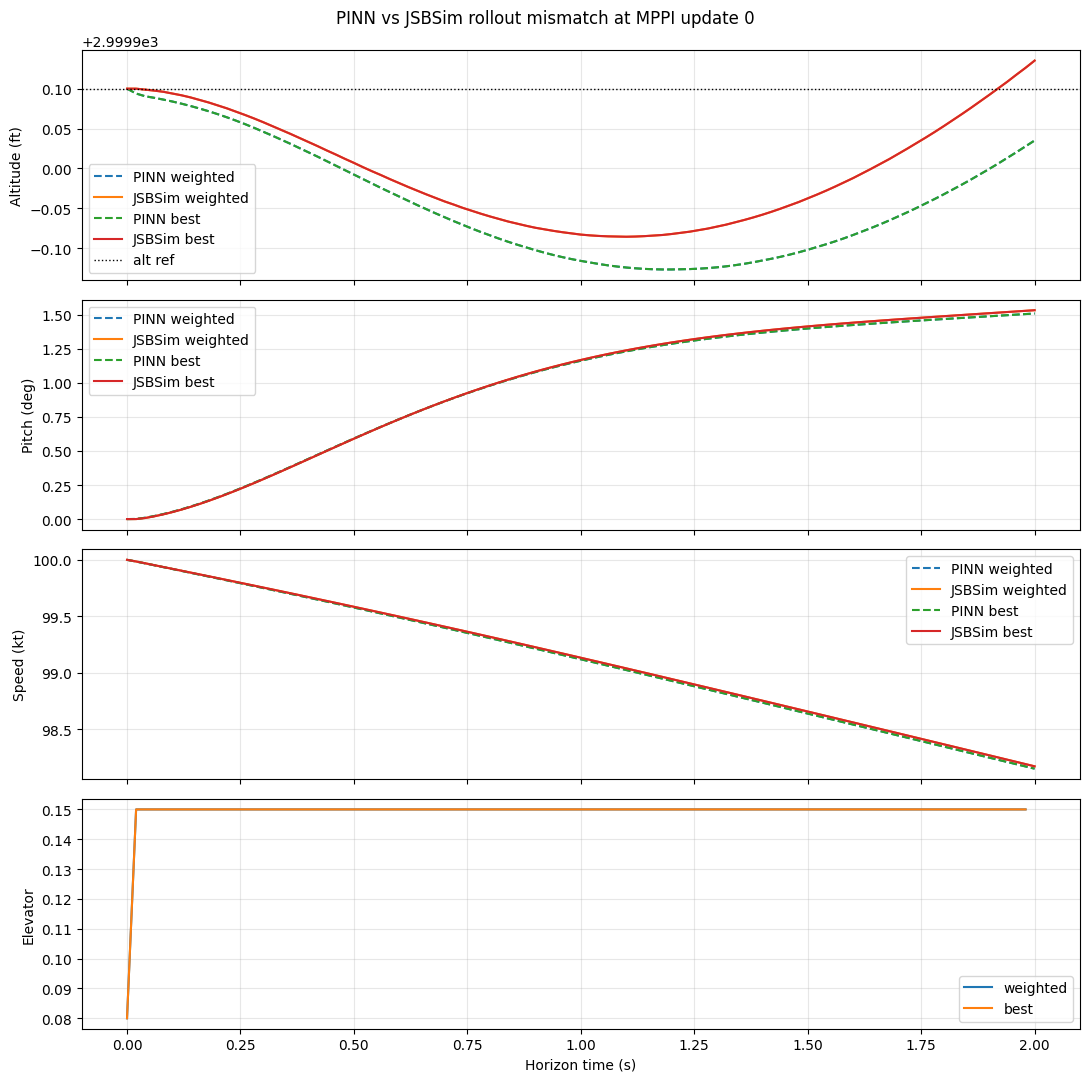

Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_snc_smooth_pitch_doublet_W0_MPPI_prediction_diagnostics_v28_fix1/archive/20260503_051021/w0_mppi_prediction_closed_loop_v28_prediction_diagnostic.png


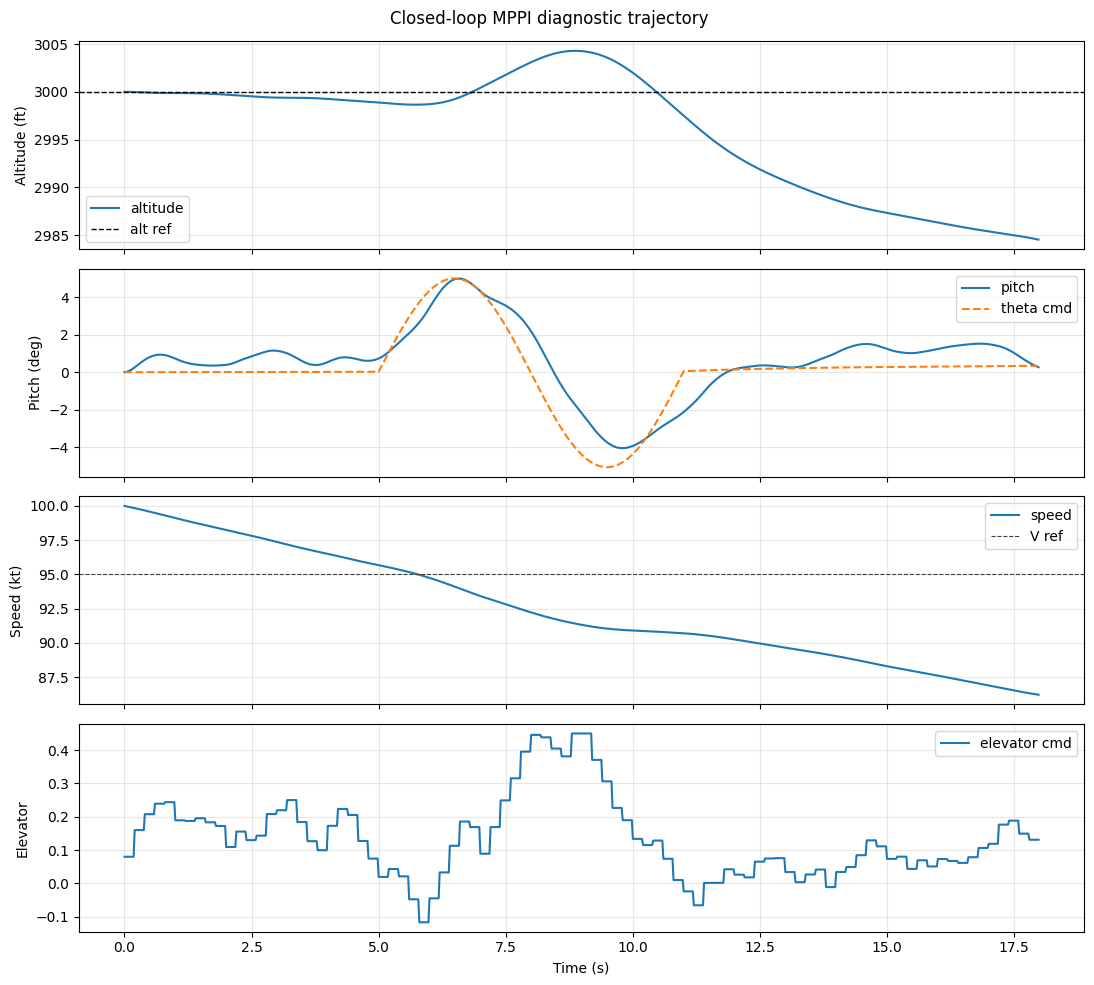

In [44]:
def plot_prediction_detail(detail, update_idx=0):
    chosen = [(idx, label, item) for idx, label, item in detail if idx == update_idx]
    if not chosen:
        raise ValueError(f'No diagnostic detail for update_idx={update_idx}')
    fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)
    t = np.arange(MPC_HORIZON + 1) * DT
    for _, label, item in chosen:
        axes[0].plot(t, item['pinn_altitude'], '--', label=f'PINN {label}')
        axes[0].plot(t, item['jsb_altitude'], label=f'JSBSim {label}')
        axes[1].plot(t, item['pinn_pitch_deg'], '--', label=f'PINN {label}')
        axes[1].plot(t, item['jsb_pitch_deg'], label=f'JSBSim {label}')
        axes[2].plot(t, item['pinn_speed_kt'], '--', label=f'PINN {label}')
        axes[2].plot(t, item['jsb_speed_kt'], label=f'JSBSim {label}')
        axes[3].plot(t[:-1], item['elevator_seq'], label=label)
    axes[0].axhline(TARGET_ALT, color='k', ls=':', lw=1.0, label='alt ref')
    axes[0].set_ylabel('Altitude (ft)')
    axes[1].set_ylabel('Pitch (deg)')
    axes[2].set_ylabel('Speed (kt)')
    axes[3].set_ylabel('Elevator')
    axes[3].set_xlabel('Horizon time (s)')
    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
    fig.suptitle(f'PINN vs JSBSim rollout mismatch at MPPI update {update_idx}')
    plt.tight_layout()
    return fig


def plot_closed_loop_diagnostic(log):
    t = np.asarray(log['time'])
    fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
    axes[0].plot(t, log['altitude'], label='altitude')
    axes[0].axhline(TARGET_ALT, color='k', ls='--', lw=1.0, label='alt ref')
    axes[1].plot(t, log['pitch_deg'], label='pitch')
    axes[1].plot(t, log['theta_cmd_deg'], '--', label='theta cmd')
    axes[2].plot(t, np.asarray(log['velocity']) / FPS_PER_KT, label='speed')
    axes[2].axhline(GUIDANCE_AIRSPEED_KTS, color='0.25', ls='--', lw=0.8, label='V ref')
    axes[3].plot(t, log['elevator_cmd'], label='elevator cmd')
    axes[0].set_ylabel('Altitude (ft)')
    axes[1].set_ylabel('Pitch (deg)')
    axes[2].set_ylabel('Speed (kt)')
    axes[3].set_ylabel('Elevator')
    axes[3].set_xlabel('Time (s)')
    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
    fig.suptitle('Closed-loop MPPI diagnostic trajectory')
    plt.tight_layout()
    return fig

plot_update = 0
fig1 = plot_prediction_detail(diagnostic_detail, update_idx=plot_update)
path1 = os.path.join(SAVE_DIR, f'w0_mppi_prediction_detail_v28_{RUN_MODE}_update{plot_update}.png')
fig1.savefig(path1, dpi=160)
print('Saved:', path1)
plt.show()

fig2 = plot_closed_loop_diagnostic(diagnostic_closed_loop)
path2 = os.path.join(SAVE_DIR, f'w0_mppi_prediction_closed_loop_v28_{RUN_MODE}.png')
fig2.savefig(path2, dpi=160)
print('Saved:', path2)
plt.show()


## 10. Optional Full Comparison


In [45]:
def make_test_cases(n_cases=N_TEST_CASES):
    cases = []
    rng = np.random.default_rng(SEED + 100)
    for i in range(n_cases):
        cases.append({
            'case': i,
            'init_alt': float(rng.uniform(2400, 4200)),
            'init_speed': float(rng.uniform(88, 112)),
            'init_pitch': float(rng.uniform(-4, 6)),
            'target_alt': float(rng.uniform(4400, 5600)),
        })
    return cases


all_logs = []
all_metrics = []

if RUN_MODE == 'full':
    cases = make_test_cases()
    for case in cases:
        print('Case:', case)
        for name in SELECTED_CONTROLLERS:
            ctrl = make_controller(name)
            log = run_sim(
                ctrl, name,
                init_alt=case['init_alt'],
                init_speed=case['init_speed'],
                init_pitch=case['init_pitch'],
                target_alt=case['target_alt'],
                max_steps=MAX_STEPS,
                control_interval=CONTROL_INTERVAL,
            )
            m = compute_metrics(log)
            m['Case'] = case['case']
            all_logs.append(log)
            all_metrics.append(m)

multi_metrics = pd.DataFrame(all_metrics)
if len(multi_metrics):
    multi_metrics.to_csv(os.path.join(SAVE_DIR, 'multi_case_metrics_v6_full.csv'), index=False)
multi_metrics


""


## 11. Save Logs


In [46]:
def logs_to_frame(logs):
    rows = []
    for idx, log in enumerate(logs):
        n = len(log['time'])
        h_ref, theta_ref_deg = maneuver_reference_for_log(log)
        for k in range(n):
            rows.append({
                'log_id': idx,
                'disturbance_case': log.get('disturbance_case', 'unknown'),
                'disturbance_kind': log.get('disturbance_kind', 'unknown'),
                'controller': log['name'],
                'time': log['time'][k],
                'altitude': log['altitude'][k],
                'guidance_altitude': float(h_ref[k]),
                'guidance_error_ft': float(log['altitude'][k] - h_ref[k]),
                'theta_ref_deg': float(theta_ref_deg[k]),
                'theta_error_deg': float(log['pitch_deg'][k] - theta_ref_deg[k]),
                'velocity': log['velocity'][k],
                'velocity_kt': float(log['velocity'][k] / FPS_PER_KT),
                'speed_ref_kt': float(GUIDANCE_AIRSPEED_KTS),
                'speed_floor_kt': float(SPEED_FLOOR_KTS),
                'pitch_deg': log['pitch_deg'][k],
                'pitch_rate_deg_s': log['pitch_rate_deg_s'][k],
                'alpha_deg': log['alpha_deg'][k],
                'elevator': log['elevator'][k],
                'elevator_cmd': log['elevator_cmd'][k],
                'elevator_disturbance': log['elevator_disturbance'][k],
                'theta_cmd_deg': log['theta_cmd_deg'][k],
                'cost': log['cost'][k],
                'comp_ms': log['comp_ms'][k],
                'mpc_update': log['mpc_update'][k],
                'target_alt': log['target_alt'],
                'init_alt': log['init_alt'],
                'control_interval': log['control_interval'],
                'abort_reason': log['abort_reason'] or 'None',
            })
    return pd.DataFrame(rows)


single_log_df = logs_to_frame(logs)
multi_log_df = logs_to_frame(all_logs)
single_log_df.to_csv(os.path.join(SAVE_DIR, f'snc_smooth_pitch_doublet_alt_hold_augmented_tracking_logs_v28_{RUN_MODE}_baseline.csv'), index=False)
multi_log_df.to_csv(os.path.join(SAVE_DIR, f'snc_smooth_pitch_doublet_alt_hold_augmented_tracking_logs_v28_{RUN_MODE}_all_cases.csv'), index=False)
sanity_df.to_csv(os.path.join(SAVE_DIR, f'cost_sanity_snc_smooth_pitch_doublet_alt_hold_augmented_v28_{RUN_MODE}.csv'), index=False)
speed_unit_df.to_csv(os.path.join(SAVE_DIR, f'speed_unit_sanity_v28_{RUN_MODE}.csv'), index=False)

config_path = os.path.join(SAVE_DIR, f'pinn_mpc_v6_alpha_snc_smooth_pitch_doublet_signed_disturbance_config_v28_{RUN_MODE}.json')
with open(config_path, 'w') as f:
    json.dump({
        'config': CONFIG,
        'pid_params': PID_PARAMS,
        'pid_optuna_best_value': None if pid_study is None else float(pid_study.best_value),
        'model_path': MODEL_PATH,
        'pinn_params': params,
        'pinn_auto_summary': checkpoint.get('auto_summary', {}),
    }, f, indent=2)

run_manifest = {
    'experiment_family': EXPERIMENT_FAMILY,
    'experiment_name': EXPERIMENT_NAME,
    'run_stamp': RUN_STAMP,
    'save_dir': SAVE_DIR,
    'latest_dir': RESULT_LATEST_DIR,
    'run_mode': RUN_MODE,
    'model_path': MODEL_PATH,
    'generated_files': sorted([name for name in os.listdir(SAVE_DIR)]),
    'plot_paths': plot_paths,
}
with open(os.path.join(SAVE_DIR, 'RUN_MANIFEST.json'), 'w') as f:
    json.dump(run_manifest, f, indent=2)
with open(os.path.join(RESULT_MODEL_DIR, 'LATEST_RUN.json'), 'w') as f:
    json.dump(run_manifest, f, indent=2)

print('Saved archived results to:', SAVE_DIR)
print('Updated latest run pointer:', os.path.join(RESULT_MODEL_DIR, 'LATEST_RUN.json'))


Saved archived results to: /content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_snc_smooth_pitch_doublet_W0_MPPI_prediction_diagnostics_v28_fix1/archive/20260503_051021
Updated latest run pointer: /content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_snc_smooth_pitch_doublet_W0_MPPI_prediction_diagnostics_v28_fix1/LATEST_RUN.json


## 12. Prediction Diagnostic Guide v28

Run this after the checkpoint load cells. Inspect:

- `diagnostic_df`: per-update weighted and best sequence summaries.
- `diagnostic_summary`: average PINN-vs-JSBSim mismatch.
- first plot: horizon-level PINN vs JSBSim altitude, pitch, speed, and elevator sequence.
- second plot: actual closed-loop MPPI trajectory.

Key decision:

- Large positive/negative `alt_prediction_error_ft` means PINN rollout mismatch.
- Small prediction error but large altitude loss means cost calibration or guidance trade-off.
